In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

MODEL_PATH = '/content/drive/MyDrive/firenet_results/firenet_fold1.keras'

print("Exists:", os.path.exists(MODEL_PATH))

Exists: True


In [7]:
from tensorflow.keras.models import load_model

model = load_model(MODEL_PATH)

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [8]:
import tensorflow as tf

conv_layers = [
    layer for layer in model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("Convolutional layers:")
for i, layer in enumerate(conv_layers):
    print(i, layer.name, layer.output.shape)

last_conv_layer = conv_layers[-1]

print("\nLast convolutional layer:")
print(last_conv_layer.name)
print(last_conv_layer.output.shape)

Convolutional layers:
0 conv2d (None, 148, 148, 32)
1 conv2d_1 (None, 72, 72, 64)
2 conv2d_2 (None, 34, 34, 128)
3 conv2d_3 (None, 15, 15, 256)
4 conv2d_4 (None, 5, 5, 512)

Last convolutional layer:
conv2d_4
(None, 5, 5, 512)


Image: /content/drive/MyDrive/FireNet_XAI/processed/test/fire/fire_test_1184.jpg
Fire probability: 0.8213755488395691
Predicted class: FIRE


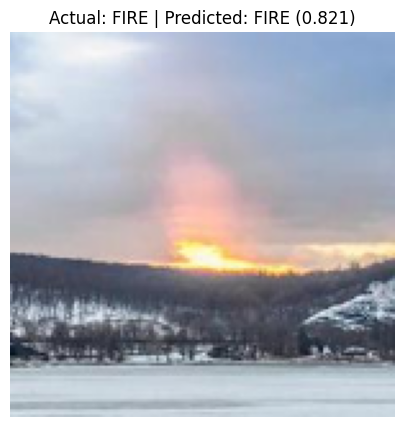

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Real test image
img_path = "/content/drive/MyDrive/FireNet_XAI/processed/test/fire/fire_test_1184.jpg"

# Load image
img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

# OpenCV BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to FireNet input size
img_resized = cv2.resize(img, (150, 150))

# Normalize exactly like training
img_input = img_resized.astype(np.float32) / 255.0

# Add batch dimension
input_tensor = np.expand_dims(img_input, axis=0)

# Predict
prediction = model.predict(input_tensor, verbose=0)[0][0]

print("Image:", img_path)
print("Fire probability:", float(prediction))
print("Predicted class:", "FIRE" if prediction >= 0.5 else "NO FIRE")

# Display
plt.figure(figsize=(5, 5))
plt.imshow(img_resized)
plt.title(
    f"Actual: FIRE | Predicted: "
    f"{'FIRE' if prediction >= 0.5 else 'NO FIRE'} "
    f"({prediction:.3f})"
)
plt.axis("off")
plt.show()

In [16]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

last_conv_layer = model.get_layer("conv2d_4")

def make_gradcam(model, image_tensor, last_conv_layer):

    # IMPORTANT: convert NumPy array to TensorFlow tensor
    image_tensor = tf.convert_to_tensor(
        image_tensor,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        # Run through the network manually
        x = image_tensor

        conv_output = None

        for layer in model.layers:
            x = layer(x)

            if layer.name == last_conv_layer.name:
                conv_output = x

        prediction = x

        # Score for FIRE class
        class_score = prediction[:, 0]

    # Gradients of FIRE score w.r.t. final convolutional feature maps
    grads = tape.gradient(
        class_score,
        conv_output
    )

    # Average gradients spatially
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_output = conv_output[0]
    pooled_grads = pooled_grads[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_output * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()


# Generate Grad-CAM
heatmap = make_gradcam(
    model,
    input_tensor,
    last_conv_layer
)

print("Grad-CAM shape:", heatmap.shape)
print("Min:", heatmap.min())
print("Max:", heatmap.max())

Grad-CAM shape: (5, 5)
Min: 0.208632
Max: 1.0


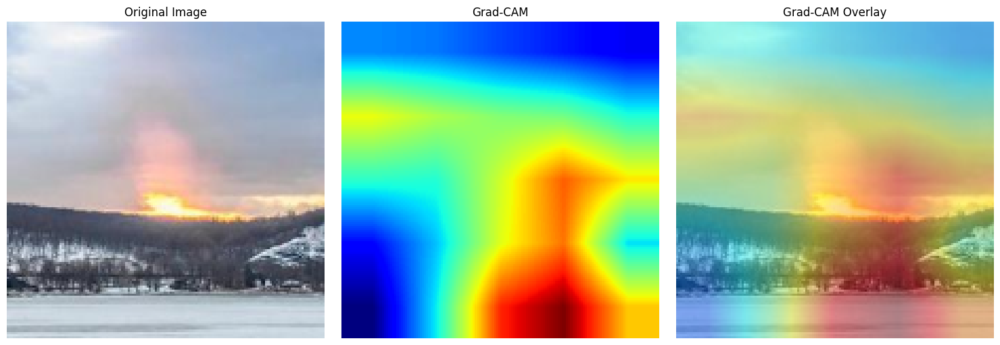

In [17]:
# Resize Grad-CAM from 5x5 → 150x150
heatmap_resized = cv2.resize(
    heatmap,
    (150, 150)
)

# Convert to color heatmap
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay on original
overlay = cv2.addWeighted(
    img_resized,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

BASE = "/content/drive/MyDrive/FireNet_XAI/processed/test"

# Pick 2 images from each class
classes = ["fire", "smokefire", "nofire", "smoke"]

selected_images = []

for cls in classes:
    files = []
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        files.extend(glob.glob(os.path.join(BASE, cls, ext)))

    random.seed(42)
    selected_images.extend(
        [(path, cls) for path in random.sample(files, min(2, len(files)))]
    )

print("Images selected:", len(selected_images))
for path, cls in selected_images:
    print(cls, "->", os.path.basename(path))

Images selected: 8
fire -> fire_test_1050.jpg
fire -> fire_test_1187.jpg
smokefire -> smokefire_test_1075.jpg
smokefire -> smokefire_test_1187.jpg
nofire -> nofire_test_1038.jpg
nofire -> nofire_test_1171.jpg
smoke -> smoke_test_1021.jpg
smoke -> smoke_test_1174.jpg


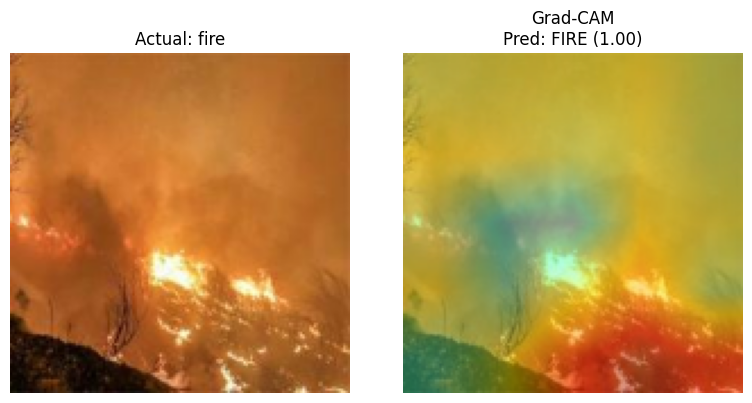

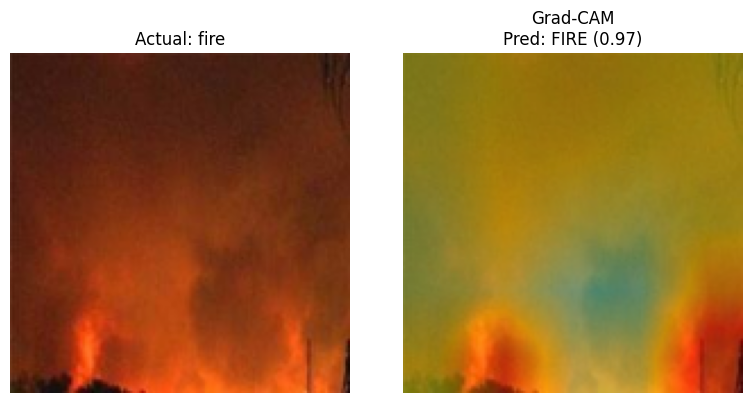

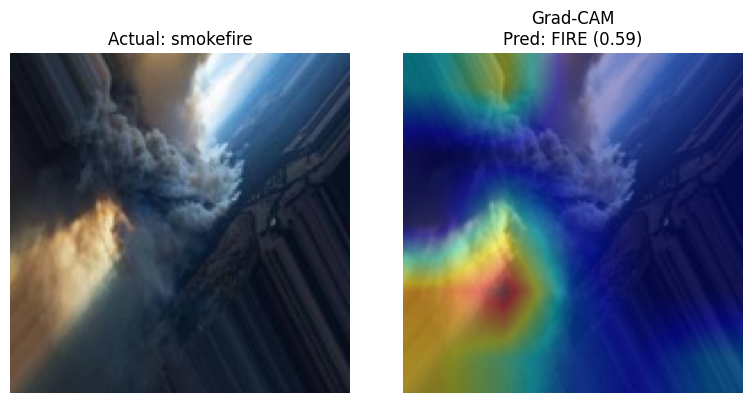

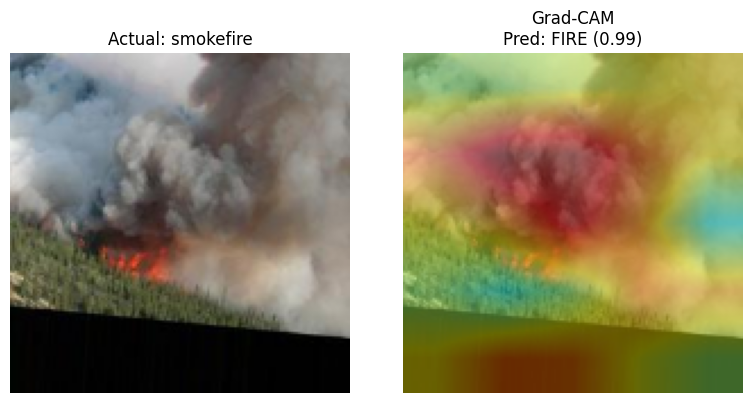

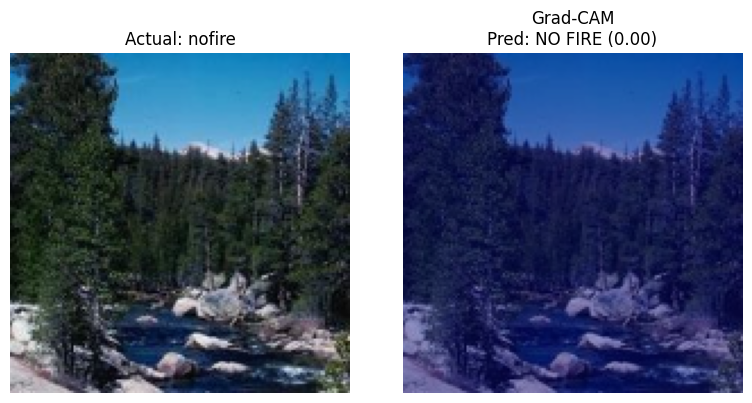

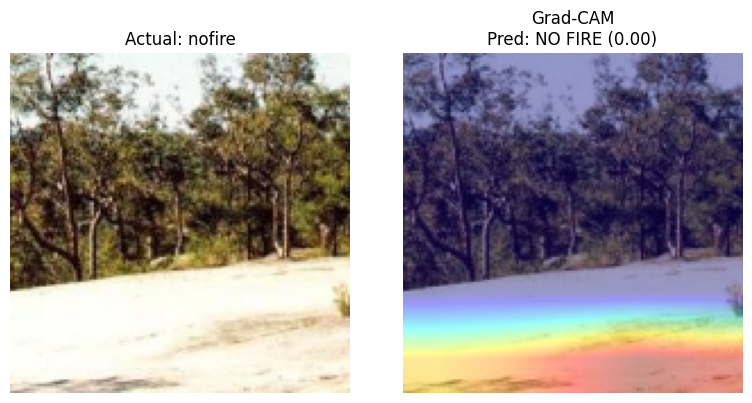

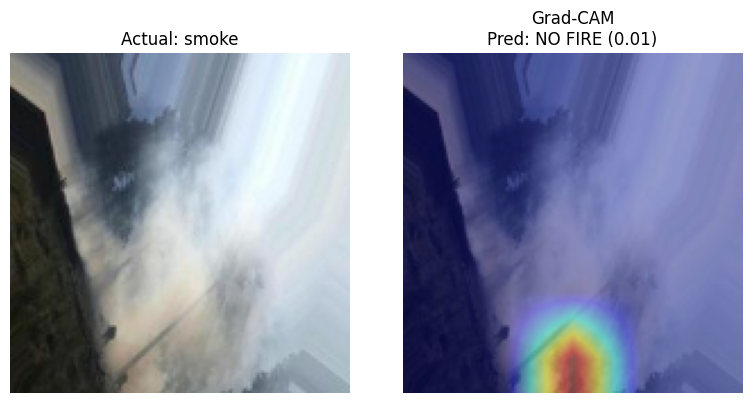

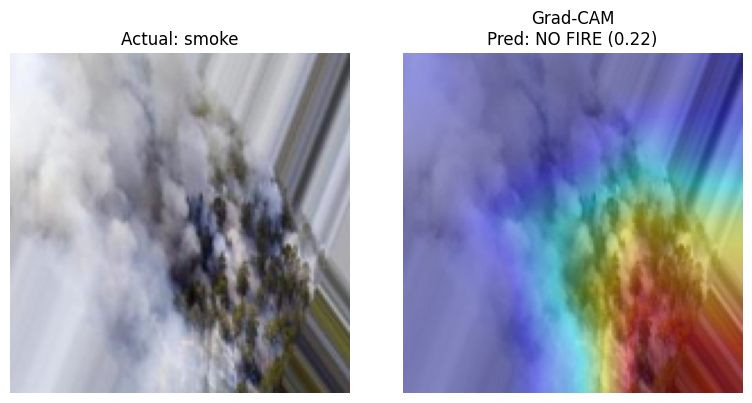

In [19]:
def get_gradcam(image_path):
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (150, 150))

    # Prepare input
    x = img_resized.astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)
    x = tf.convert_to_tensor(x, dtype=tf.float32)

    # Grad-CAM
    with tf.GradientTape() as tape:
        intermediate = x
        conv_output = None

        for layer in model.layers:
            intermediate = layer(intermediate)

            if layer.name == "conv2d_4":
                conv_output = intermediate

        prediction = intermediate
        score = prediction[:, 0]

    grads = tape.gradient(score, conv_output)

    # Channel weights
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    conv_output = conv_output[0]
    pooled_grads = pooled_grads[0]

    heatmap = tf.reduce_sum(
        conv_output * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)

    if max_val > 0:
        heatmap /= max_val

    heatmap = heatmap.numpy()

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (150, 150))

    # Color heatmap
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        img_resized,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    return img_resized, overlay, float(prediction[0][0])


# Create individual figures
for i, (path, actual_class) in enumerate(selected_images):

    original, overlay, probability = get_gradcam(path)

    predicted = "FIRE" if probability >= 0.5 else "NO FIRE"

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(f"Actual: {actual_class}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(
        f"Grad-CAM\nPred: {predicted} ({probability:.2f})"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [20]:
def make_saliency_map(model, image_tensor):

    # Convert to TensorFlow tensor
    image_tensor = tf.convert_to_tensor(
        image_tensor,
        dtype=tf.float32
    )

    with tf.GradientTape() as tape:

        # We need gradients with respect to the input image
        tape.watch(image_tensor)

        prediction = model(image_tensor)

        # FIRE score
        score = prediction[:, 0]

    # Gradient of FIRE score with respect to input pixels
    gradients = tape.gradient(
        score,
        image_tensor
    )

    # Absolute gradients
    saliency = tf.abs(gradients)

    # Take maximum across RGB channels
    saliency = tf.reduce_max(
        saliency,
        axis=-1
    )

    # Remove batch dimension
    saliency = saliency[0]

    # Normalize to 0–1
    saliency = (
        saliency - tf.reduce_min(saliency)
    ) / (
        tf.reduce_max(saliency)
        - tf.reduce_min(saliency)
        + 1e-8
    )

    return saliency.numpy()

In [21]:
# Generate saliency map
saliency = make_saliency_map(
    model,
    input_tensor
)

print("Saliency shape:", saliency.shape)
print("Min:", saliency.min())
print("Max:", saliency.max())

Saliency shape: (150, 150)
Min: 0.0
Max: 0.99999994


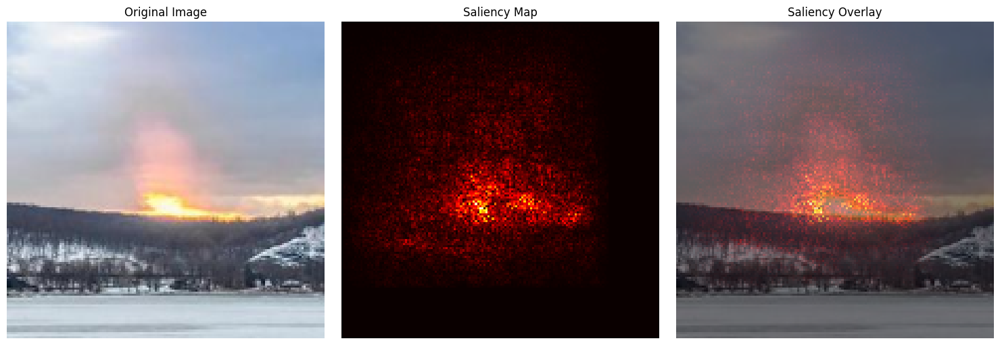

In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(saliency, cmap="hot")
plt.title("Saliency Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_resized)
plt.imshow(saliency, cmap="hot", alpha=0.5)
plt.title("Saliency Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

Saved successfully:
/content/drive/MyDrive/firenet_results/XAI/fire_test_1184_XAI.png


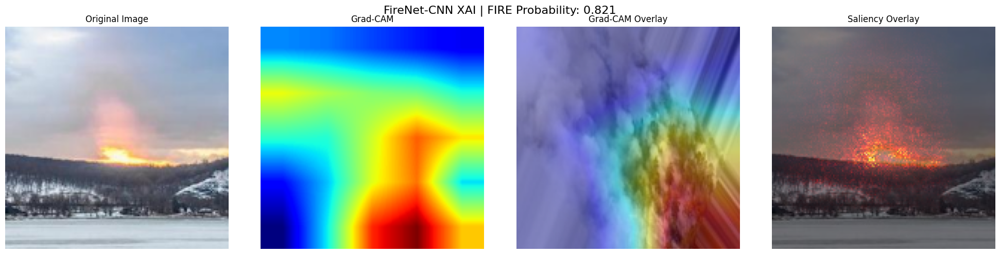

In [25]:
import os
import matplotlib.pyplot as plt

XAI_DIR = "/content/drive/MyDrive/firenet_results/XAI"
os.makedirs(XAI_DIR, exist_ok=True)

save_path = os.path.join(
    XAI_DIR,
    "fire_test_1184_XAI.png"
)

# Create a NEW figure
fig = plt.figure(figsize=(20, 5))

# 1. Original
ax1 = fig.add_subplot(1, 4, 1)
ax1.imshow(img_resized)
ax1.set_title("Original Image")
ax1.axis("off")

# 2. Grad-CAM
ax2 = fig.add_subplot(1, 4, 2)
ax2.imshow(heatmap_resized, cmap="jet")
ax2.set_title("Grad-CAM")
ax2.axis("off")

# 3. Grad-CAM Overlay
ax3 = fig.add_subplot(1, 4, 3)
ax3.imshow(overlay)
ax3.set_title("Grad-CAM Overlay")
ax3.axis("off")

# 4. Saliency Overlay
ax4 = fig.add_subplot(1, 4, 4)
ax4.imshow(img_resized)
ax4.imshow(saliency, cmap="hot", alpha=0.5)
ax4.set_title("Saliency Overlay")
ax4.axis("off")

fig.suptitle(
    f"FireNet-CNN XAI | FIRE Probability: {prediction:.3f}",
    fontsize=16
)

fig.tight_layout()

# SAVE BEFORE SHOW
fig.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved successfully:")
print(save_path)

# Now display
plt.show()

In [24]:
XAI_DIR = "/content/drive/MyDrive/firenet_results/XAI"
os.makedirs(XAI_DIR, exist_ok=True)

save_path = os.path.join(
    XAI_DIR,
    "fire_test_1184_XAI.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", save_path)

Saved: /content/drive/MyDrive/firenet_results/XAI/fire_test_1184_XAI.png


<Figure size 640x480 with 0 Axes>

Selected: 8 images


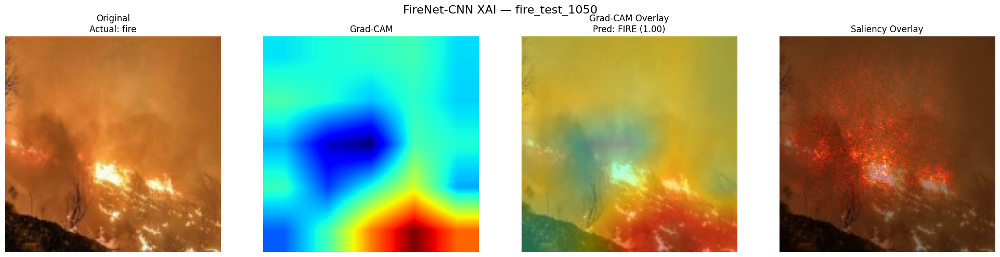

1/8 saved: /content/drive/MyDrive/firenet_results/XAI/fire_test_1050_XAI.png | Actual: fire | Prediction: FIRE | Probability: 0.9969


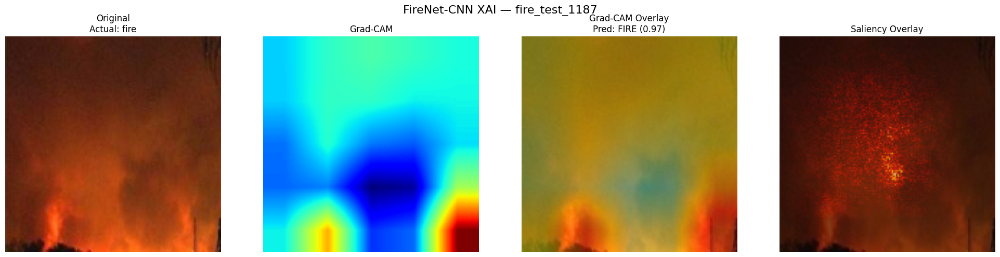

2/8 saved: /content/drive/MyDrive/firenet_results/XAI/fire_test_1187_XAI.png | Actual: fire | Prediction: FIRE | Probability: 0.9707


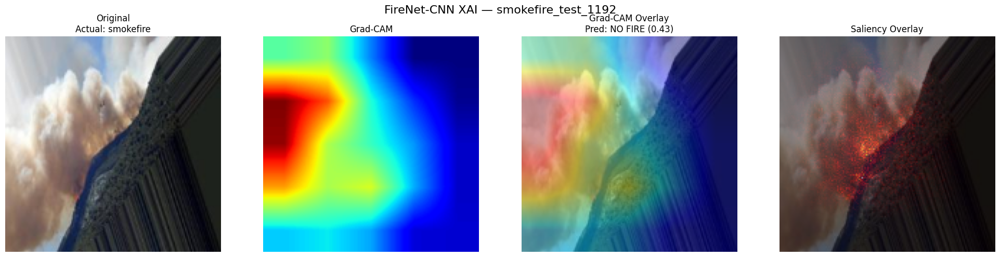

3/8 saved: /content/drive/MyDrive/firenet_results/XAI/smokefire_test_1192_XAI.png | Actual: smokefire | Prediction: NO FIRE | Probability: 0.4277


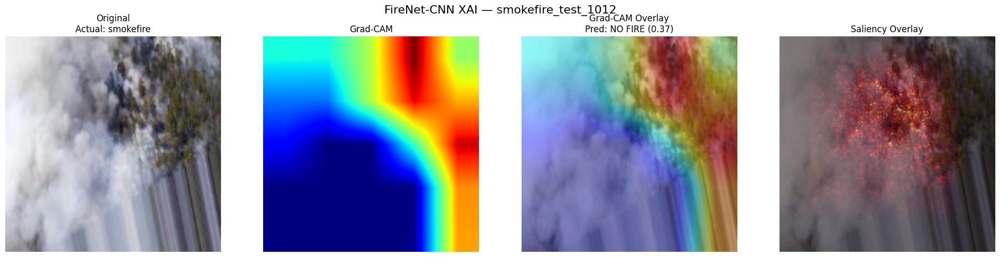

4/8 saved: /content/drive/MyDrive/firenet_results/XAI/smokefire_test_1012_XAI.png | Actual: smokefire | Prediction: NO FIRE | Probability: 0.3655


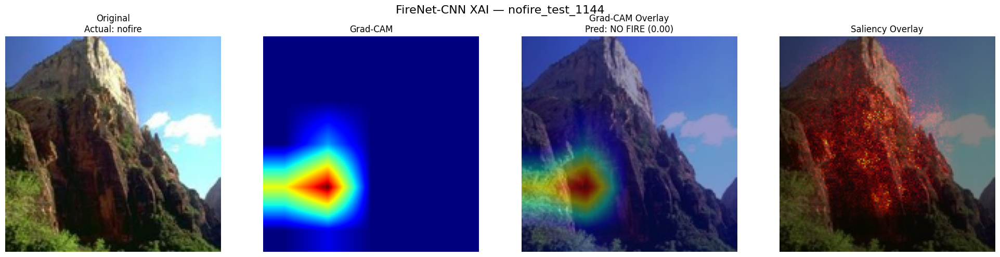

5/8 saved: /content/drive/MyDrive/firenet_results/XAI/nofire_test_1144_XAI.png | Actual: nofire | Prediction: NO FIRE | Probability: 0.0000


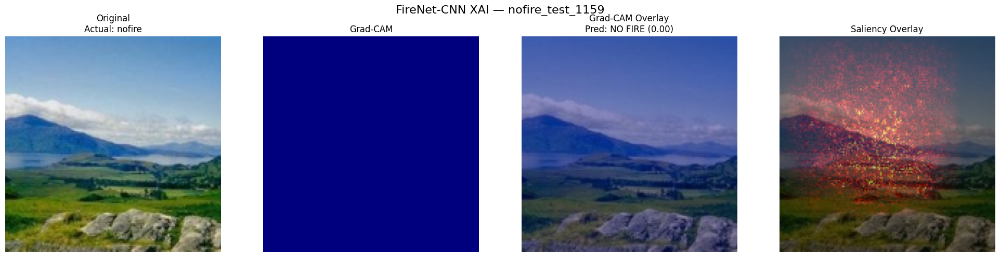

6/8 saved: /content/drive/MyDrive/firenet_results/XAI/nofire_test_1159_XAI.png | Actual: nofire | Prediction: NO FIRE | Probability: 0.0000


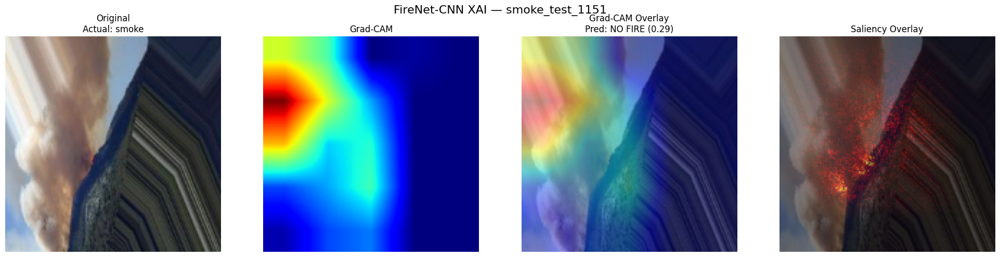

7/8 saved: /content/drive/MyDrive/firenet_results/XAI/smoke_test_1151_XAI.png | Actual: smoke | Prediction: NO FIRE | Probability: 0.2868


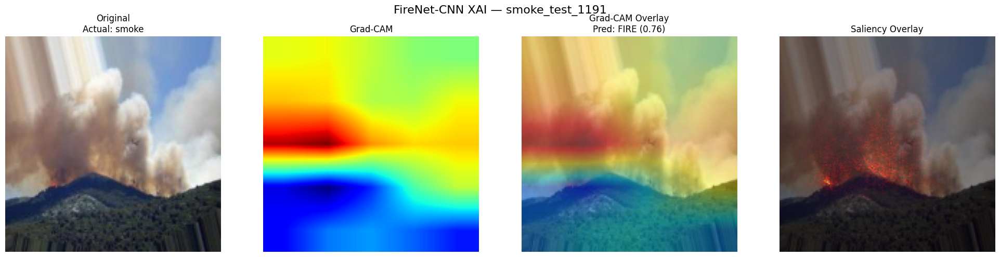

8/8 saved: /content/drive/MyDrive/firenet_results/XAI/smoke_test_1191_XAI.png | Actual: smoke | Prediction: FIRE | Probability: 0.7583

DONE — XAI figures saved to:
/content/drive/MyDrive/firenet_results/XAI


In [26]:
import os
import glob
import random
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/FireNet_XAI/processed/test"
XAI_DIR = "/content/drive/MyDrive/firenet_results/XAI"

os.makedirs(XAI_DIR, exist_ok=True)

classes = ["fire", "smokefire", "nofire", "smoke"]

# --------------------------------------------------
# Grad-CAM + Saliency function
# --------------------------------------------------

def explain_image(image_path):

    # Load image
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (150, 150))

    # Prepare input
    x = img_resized.astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)
    x = tf.convert_to_tensor(x, dtype=tf.float32)

    # ==================================================
    # GRAD-CAM
    # ==================================================

    with tf.GradientTape() as tape:

        intermediate = x
        conv_output = None

        for layer in model.layers:
            intermediate = layer(intermediate)

            if layer.name == "conv2d_4":
                conv_output = intermediate

        prediction_tensor = intermediate
        score = prediction_tensor[:, 0]

    grads = tape.gradient(score, conv_output)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_output = conv_output[0]
    pooled_grads = pooled_grads[0]

    heatmap = tf.reduce_sum(
        conv_output * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    heatmap = heatmap.numpy()

    # Resize 5x5 -> 150x150
    heatmap_resized = cv2.resize(
        heatmap,
        (150, 150)
    )

    # Color
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    gradcam_overlay = cv2.addWeighted(
        img_resized,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # ==================================================
    # SALIENCY
    # ==================================================

    with tf.GradientTape() as tape:

        tape.watch(x)

        prediction = model(x)

        score = prediction[:, 0]

    gradients = tape.gradient(
        score,
        x
    )

    saliency = tf.abs(gradients)

    saliency = tf.reduce_max(
        saliency,
        axis=-1
    )

    saliency = saliency[0]

    # Normalize
    saliency = (
        saliency - tf.reduce_min(saliency)
    ) / (
        tf.reduce_max(saliency)
        - tf.reduce_min(saliency)
        + 1e-8
    )

    saliency = saliency.numpy()

    # ==================================================
    # RETURN
    # ==================================================

    return (
        img_resized,
        heatmap_resized,
        gradcam_overlay,
        saliency,
        float(prediction_tensor[0, 0])
    )


# --------------------------------------------------
# Select 2 images per class
# --------------------------------------------------

selected_images = []

random.seed(42)

for cls in classes:

    files = []

    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        files.extend(
            glob.glob(
                os.path.join(BASE, cls, ext)
            )
        )

    chosen = random.sample(
        files,
        min(2, len(files))
    )

    for path in chosen:
        selected_images.append(
            (path, cls)
        )


print("Selected:", len(selected_images), "images")

# --------------------------------------------------
# Generate + save
# --------------------------------------------------

for i, (path, actual_class) in enumerate(selected_images):

    (
        original,
        heatmap,
        gradcam_overlay,
        saliency,
        probability
    ) = explain_image(path)

    predicted = (
        "FIRE"
        if probability >= 0.5
        else "NO FIRE"
    )

    filename = os.path.splitext(
        os.path.basename(path)
    )[0]

    save_path = os.path.join(
        XAI_DIR,
        filename + "_XAI.png"
    )

    # Figure
    fig = plt.figure(figsize=(20, 5))

    ax1 = fig.add_subplot(1, 4, 1)
    ax1.imshow(original)
    ax1.set_title(
        f"Original\nActual: {actual_class}"
    )
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 4, 2)
    ax2.imshow(heatmap, cmap="jet")
    ax2.set_title("Grad-CAM")
    ax2.axis("off")

    ax3 = fig.add_subplot(1, 4, 3)
    ax3.imshow(gradcam_overlay)
    ax3.set_title(
        f"Grad-CAM Overlay\nPred: {predicted} ({probability:.2f})"
    )
    ax3.axis("off")

    ax4 = fig.add_subplot(1, 4, 4)
    ax4.imshow(original)
    ax4.imshow(
        saliency,
        cmap="hot",
        alpha=0.5
    )
    ax4.set_title("Saliency Overlay")
    ax4.axis("off")

    fig.suptitle(
        f"FireNet-CNN XAI — {filename}",
        fontsize=16
    )

    fig.tight_layout()

    # Save BEFORE show
    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        f"{i+1}/8 saved:",
        save_path,
        "| Actual:", actual_class,
        "| Prediction:", predicted,
        f"| Probability: {probability:.4f}"
    )

print("\nDONE — XAI figures saved to:")
print(XAI_DIR)

In [29]:
# ============================================================
# QUICK DATA RECONSTRUCTION FOR ABLATION STUDY
# ============================================================

import os
import glob
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

DATA_ROOT = "/content/drive/MyDrive/FireNet_XAI/processed/train"

# Paper's binary setup:
# fire + smokefire = FIRE = 1
# nofire + smoke   = NO FIRE = 0

class_map = {
    "fire": 1,
    "smokefire": 1,
    "nofire": 0,
    "smoke": 0
}

X_list = []
y_list = []

for class_name, label in class_map.items():

    folder = os.path.join(DATA_ROOT, class_name)

    files = []

    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        files.extend(
            glob.glob(os.path.join(folder, ext))
        )

    print(class_name, ":", len(files))

    for path in files:

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = cv2.resize(
            img,
            (150, 150)
        )

        img = img.astype(np.float32) / 255.0

        X_list.append(img)
        y_list.append(label)


X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)

print("\nDataset loaded!")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass counts:")
print("NO FIRE:", np.sum(y == 0))
print("FIRE:", np.sum(y == 1))


# 80/20 stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)

fire : 802
smokefire : 800
nofire : 800
smoke : 800

Dataset loaded!
X shape: (3202, 150, 150, 3)
y shape: (3202,)

Class counts:
NO FIRE: 1600
FIRE: 1602

Train: (2561, 150, 150, 3)
Validation: (641, 150, 150, 3)


Training images: 2561
Validation images: 641

RUNNING: No Convolution
Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 57s 653ms/step - accuracy: 0.7317 - loss: 1.1502 - val_accuracy: 0.8612 - val_loss: 0.3726
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 79s 638ms/step - accuracy: 0.8149 - loss: 0.4398 - val_accuracy: 0.8690 - val_loss: 0.3484
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 80s 615ms/step - accuracy: 0.8192 - loss: 0.4314 - val_accuracy: 0.8534 - val_loss: 0.3466
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 617ms/step - accuracy: 0.8380 - loss: 0.4017 - val_accuracy: 0.8768 - val_loss: 0.3323
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 51s 634ms/step - accuracy: 0.8083 - loss: 0.4207 - val_accuracy: 0.8658 - val_loss: 0.3267
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 81s 622ms/step - accuracy: 0.7966 - loss: 0.4439 - val_accuracy: 0.8300 - val_loss: 0.3785
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 53s 654ms/step - accuracy: 0.8227 - loss: 0.4182 - val_accuracy: 0.8877 - val_loss: 0.3220
Epoch 8/10
81/81 ━━━━━━━━━━

,Model,Training Accuracy,Validation Accuracy,Precision,Recall,F1 Score
0,No Convolution,83.91,88.77,94.62,82.24,88.00
1,LeakyReLU,94.06,95.16,97.39,92.83,95.06
2,Sigmoid Activation,92.82,93.76,95.47,91.90,93.65
3,No Dropout,98.40,94.70,97.36,91.90,94.55
4,No BatchNorm,94.53,95.32,95.33,95.33,95.33
5,SGD Optimizer,74.46,50.08,50.08,100.00,66.74
6,RMSProp Optimizer,95.43,94.23,96.71,91.59,94.08
7,MSE Loss,91.60,50.23,50.16,100.00,66.81



Saved: /content/drive/MyDrive/firenet_results/ablation/ablation_results.csv


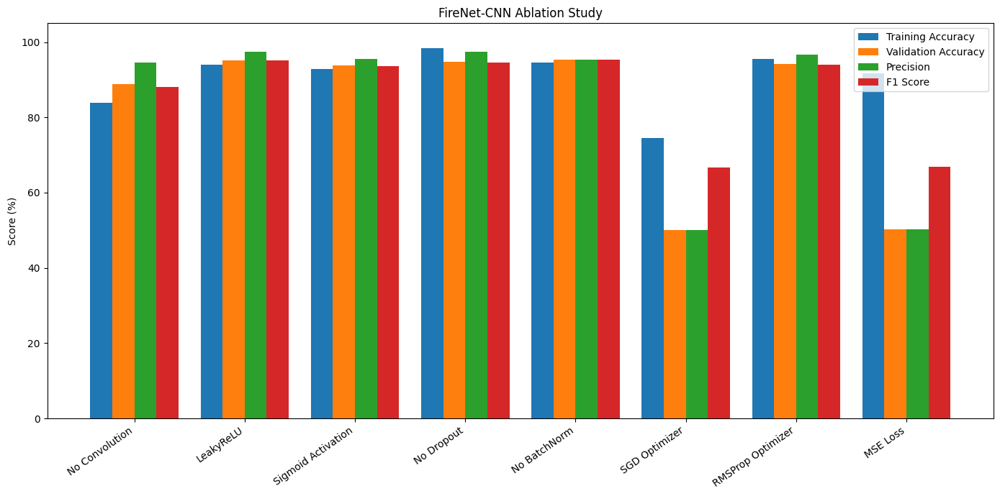


Plot saved: /content/drive/MyDrive/firenet_results/ablation/ablation_comparison.png


In [30]:
# ============================================================
# FIRENET-CNN — PAPER-BASED ABLATION STUDY
# Quick version for limited time
# ============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

EPOCHS = 10
BATCH_SIZE = 32

SAVE_DIR = "/content/drive/MyDrive/firenet_results/ablation"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# USE THE SAME FIRST FOLD AS YOUR FIReNET EXPERIMENT
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))

# ------------------------------------------------------------
# MODEL BUILDER
# ------------------------------------------------------------

def build_ablation_model(
    activation="relu",
    use_conv=True,
    use_dropout=True,
    use_batchnorm=True
):

    model = models.Sequential(name="FireNet_Ablation")

    model.add(
        layers.Input(shape=(150, 150, 3))
    )

    # ========================================================
    # CONVOLUTIONAL PART
    # ========================================================

    if use_conv:

        for filters in [32, 64, 128, 256, 512]:

            model.add(
                layers.Conv2D(
                    filters,
                    (3, 3),
                    padding="valid"
                )
            )

            # Activation
            if activation == "leaky_relu":
                model.add(
                    layers.LeakyReLU(negative_slope=0.01)
                )
            else:
                model.add(
                    layers.Activation(activation)
                )

            model.add(
                layers.MaxPooling2D((2, 2))
            )

            if use_batchnorm:
                model.add(
                    layers.BatchNormalization()
                )

    # ========================================================
    # FULLY CONNECTED PART
    # ========================================================

    model.add(layers.Flatten())

    model.add(
        layers.Dense(512)
    )

    if activation == "leaky_relu":
        model.add(
            layers.LeakyReLU(negative_slope=0.01)
        )
    else:
        model.add(
            layers.Activation(activation)
        )

    if use_dropout:
        model.add(
            layers.Dropout(0.5)
        )

    model.add(
        layers.Dense(256)
    )

    if activation == "leaky_relu":
        model.add(
            layers.LeakyReLU(negative_slope=0.01)
        )
    else:
        model.add(
            layers.Activation(activation)
        )

    if use_dropout:
        model.add(
            layers.Dropout(0.5)
        )

    # Binary output
    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model


# ------------------------------------------------------------
# ABLATION CONFIGURATIONS FROM PAPER
# ------------------------------------------------------------

configs = {

    "No Convolution": {
        "activation": "relu",
        "use_conv": False,
        "use_dropout": True,
        "use_batchnorm": False,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    },

    "LeakyReLU": {
        "activation": "leaky_relu",
        "use_conv": True,
        "use_dropout": True,
        "use_batchnorm": True,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    },

    "Sigmoid Activation": {
        "activation": "sigmoid",
        "use_conv": True,
        "use_dropout": True,
        "use_batchnorm": True,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    },

    "No Dropout": {
        "activation": "relu",
        "use_conv": True,
        "use_dropout": False,
        "use_batchnorm": True,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    },

    "No BatchNorm": {
        "activation": "relu",
        "use_conv": True,
        "use_dropout": True,
        "use_batchnorm": False,
        "optimizer": "adam",
        "loss": "binary_crossentropy"
    },

    "SGD Optimizer": {
        "activation": "relu",
        "use_conv": True,
        "use_dropout": True,
        "use_batchnorm": True,
        "optimizer": "sgd",
        "loss": "binary_crossentropy"
    },

    "RMSProp Optimizer": {
        "activation": "relu",
        "use_conv": True,
        "use_dropout": True,
        "use_batchnorm": True,
        "optimizer": "rmsprop",
        "loss": "binary_crossentropy"
    },

    "MSE Loss": {
        "activation": "relu",
        "use_conv": True,
        "use_dropout": True,
        "use_batchnorm": True,
        "optimizer": "adam",
        "loss": "mse"
    }
}


# ------------------------------------------------------------
# TRAIN + EVALUATE
# ------------------------------------------------------------

results = []

for name, cfg in configs.items():

    print("\n" + "=" * 65)
    print("RUNNING:", name)
    print("=" * 65)

    tf.keras.backend.clear_session()

    # Build
    ablation_model = build_ablation_model(
        activation=cfg["activation"],
        use_conv=cfg["use_conv"],
        use_dropout=cfg["use_dropout"],
        use_batchnorm=cfg["use_batchnorm"]
    )

    # Optimizer
    if cfg["optimizer"] == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=1e-4
        )

    elif cfg["optimizer"] == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=1e-4
        )

    elif cfg["optimizer"] == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=1e-4
        )

    # Compile
    ablation_model.compile(
        optimizer=optimizer,
        loss=cfg["loss"],
        metrics=["accuracy"]
    )

    # Train
    history = ablation_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            )
        ]
    )

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    probabilities = ablation_model.predict(
        X_val,
        batch_size=64,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    acc = accuracy_score(
        y_val,
        predictions
    )

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    train_acc = max(
        history.history["accuracy"]
    )

    val_acc = max(
        history.history["val_accuracy"]
    )

    results.append({
        "Model": name,
        "Training Accuracy": train_acc * 100,
        "Validation Accuracy": acc * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1 Score": f1 * 100
    })

    print("\nRESULT:")
    print("Training Accuracy :", f"{train_acc*100:.2f}%")
    print("Validation Accuracy:", f"{acc*100:.2f}%")
    print("Precision         :", f"{precision*100:.2f}%")
    print("Recall            :", f"{recall*100:.2f}%")
    print("F1 Score          :", f"{f1*100:.2f}%")


# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n" + "=" * 80)
print("ABLATION STUDY RESULTS")
print("=" * 80)

display(
    results_df.round(2)
)

# Save CSV
csv_path = os.path.join(
    SAVE_DIR,
    "ablation_results.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)

print("\nSaved:", csv_path)


# ------------------------------------------------------------
# BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

x = np.arange(len(results_df))
width = 0.2

plt.bar(
    x - 1.5 * width,
    results_df["Training Accuracy"],
    width,
    label="Training Accuracy"
)

plt.bar(
    x - 0.5 * width,
    results_df["Validation Accuracy"],
    width,
    label="Validation Accuracy"
)

plt.bar(
    x + 0.5 * width,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + 1.5 * width,
    results_df["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=35,
    ha="right"
)

plt.ylabel("Score (%)")
plt.title("FireNet-CNN Ablation Study")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()

plot_path = os.path.join(
    SAVE_DIR,
    "ablation_comparison.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nPlot saved:", plot_path)

In [28]:
print("X:", X.shape)
print("y:", y.shape)

NameError: name 'X' is not defined